# 1-stage gradient-to-mask pipeline

This notebook trains the official one-stage model at five training-noise levels. Raw runs are stored under `output/stage_one/runs/`; grouped research artifacts are stored under `output/stage_one/`, and curated copies are published under `expected_output/stage_one/`. The clean test row is the official protocol result; noisy-test rows are supplementary robustness results.

## Architecture

## Architecture

The architecture is a hybrid MLP and convolutional decoder:

22 gradient features -> MLP projection -> 160 x 16 x 16 latent feature map -> convolutional decoder -> 32 x 32 mask logits.

The MLP projection uses Linear(22 -> 512), ReLU, Dropout(0.1), Linear(512 -> 1024), ReLU, Dropout(0.1), and Linear(1024 -> 40960). The final vector is reshaped to the latent feature map.

The convolutional decoder uses Conv2d(160 -> 160), Conv2d(160 -> 128), Conv2d(128 -> 96), Conv2d(96 -> 64), and Conv2d(64 -> 32). Each block contains BatchNorm and ReLU. Two coordinate channels, x and y, are added before the final Conv2d(34 -> 1) output layer. Coordinate channels provide explicit pixel-position information.

Training uses BCE loss, Dice loss, optional boundary weighting, Adam, dropout, and early stopping based on validation loss. The official preset uses 20,000 training samples, 2,000 validation samples, 1,000 test samples, 170 maximum epochs, and batch size 96.

For one-stage reconstruction, N controls the number of gradient features entering the model. Unlike the two-stage system, there is no intermediate coefficient prediction whose errors propagate into a second model.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import torch

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from config.official import OFFICIAL_TRAIN_SIGMAS, official_one_stage_config
from datasets import build_two_stage_datasets
from experiments import (layer_table, load_one_stage_predictor, parameter_count, publish_expected_output, publish_run_artifacts)
from experiments.notebook import plot_history
from workflows.one_model import run_one_model
from models.one_model import GradientToMaskModel

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT = ROOT / 'output' / 'stage_one'
TRAIN_SIGMAS = OFFICIAL_TRAIN_SIGMAS
RUN_TRAINING = False  # Missing checkpoints automatically trigger training.

def make_config(train_sigma):
    return official_one_stage_config(train_sigma, output_root=ROOT / 'output')

model_check = GradientToMaskModel(input_dim=2 * 11, output_dim=32 * 32, hidden_dims=(512, 1024), dropout_rates=(0.1, 0.1), latent_grid_size=16, latent_channels=160, decoder_channels=(160, 128, 96, 64, 32))
architecture = layer_table(model_check, torch.zeros(2, 22))
print('Device:', DEVICE, 'parameters:', parameter_count(model_check))
display(architecture)

Device: cuda parameters: {'total': 43121603, 'trainable': 43121603}


,layer,type,output_shape,parameters,trainable
0,projection.0,Linear,"(2, 512)",11776,11776
1,projection.1,ReLU,"(2, 512)",0,0
2,projection.2,Dropout,"(2, 512)",0,0
3,projection.3,Linear,"(2, 1024)",525312,525312
4,projection.4,ReLU,"(2, 1024)",0,0
5,projection.5,Dropout,"(2, 1024)",0,0
6,projection.6,Linear,"(2, 40960)",41984000,41984000
7,decoder.0,Conv2d,"(2, 160, 16, 16)",230560,230560
8,decoder.1,BatchNorm2d,"(2, 160, 16, 16)",320,320
9,decoder.2,ReLU,"(2, 160, 16, 16)",0,0



=== training sigma=0 ===


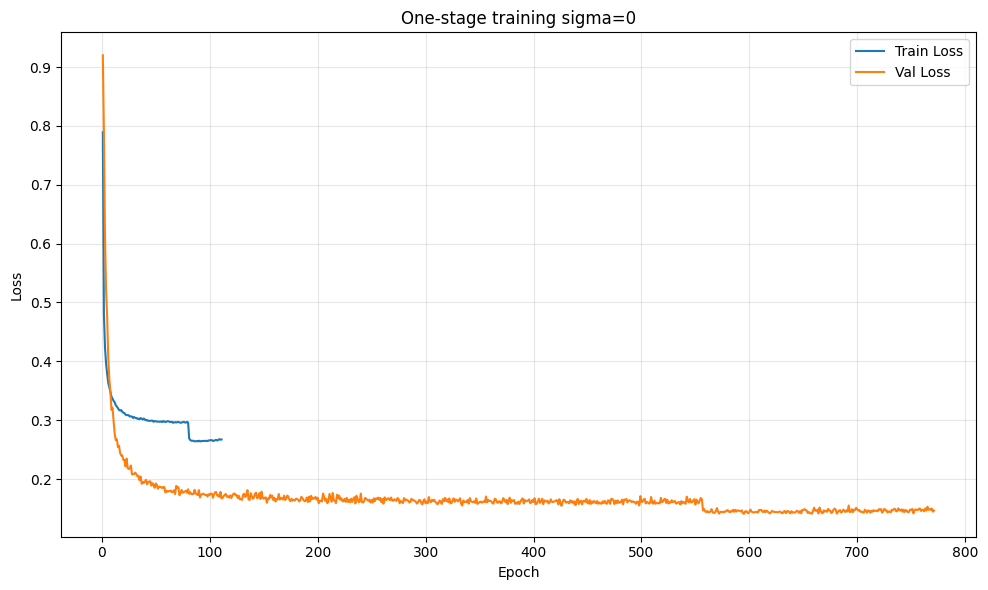


=== training sigma=0.001 ===


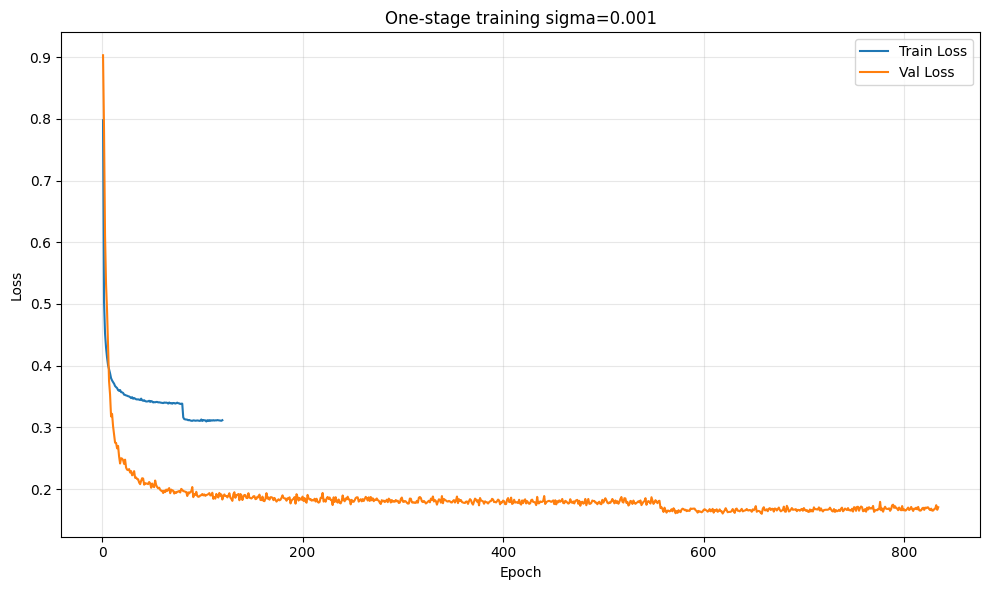


=== training sigma=0.0025 ===


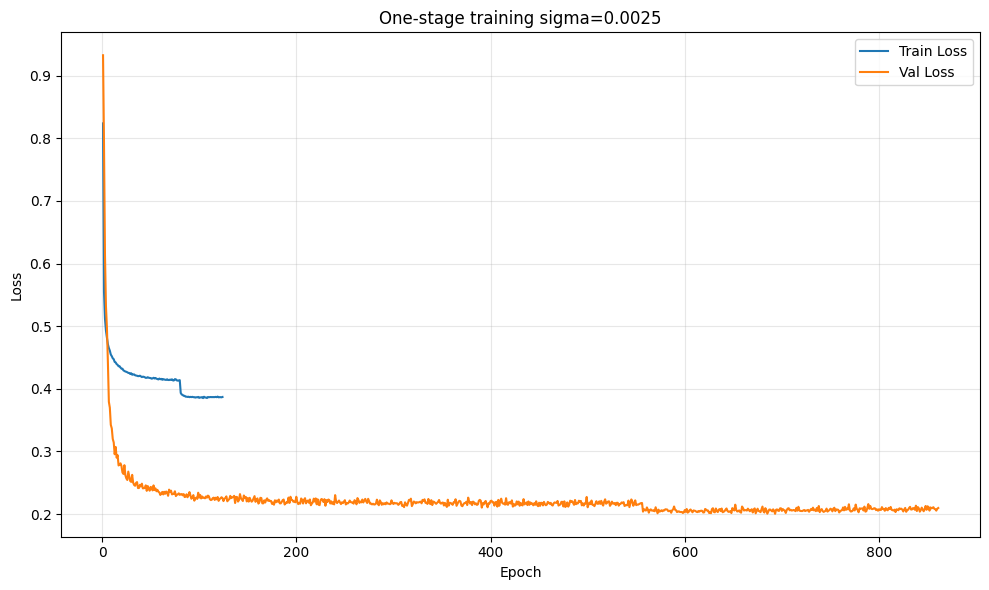


=== training sigma=0.005 ===


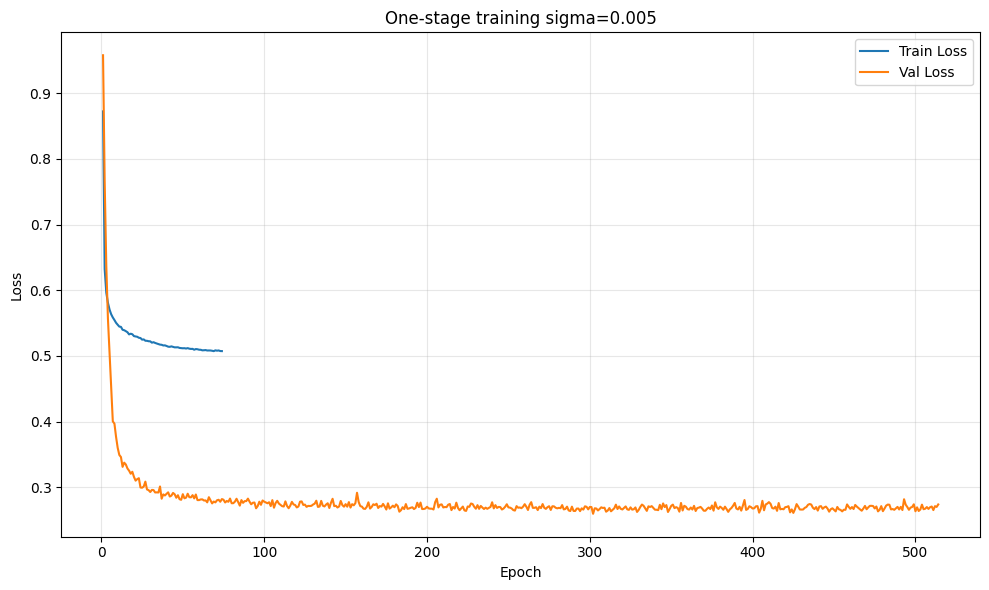


=== training sigma=0.01 ===


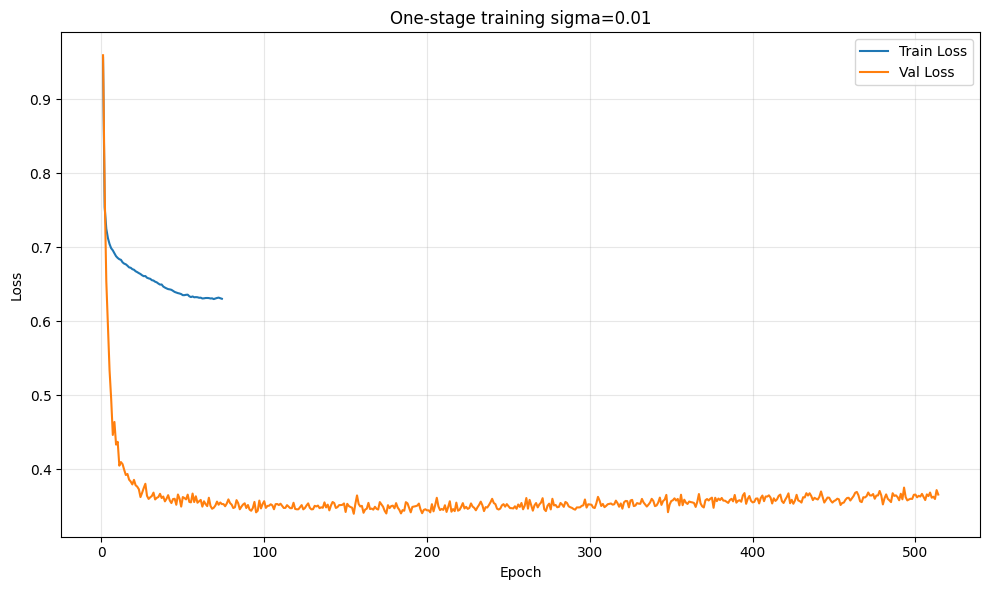

,train_sigma,clean_test_iou,clean_pixel_accuracy,threshold
0,0.0000,0.855442,0.986185,0.50
1,0.0010,0.834170,0.984785,0.50
2,0.0025,0.793733,0.981423,0.50
3,0.0050,0.739343,0.976711,0.55
4,0.0100,0.678906,0.969688,0.45


In [2]:
comparison_rows = []
for train_sigma in TRAIN_SIGMAS:
    config = make_config(train_sigma)
    summary_path = config.run_output_dir / 'summary.json'
    should_train = RUN_TRAINING or not summary_path.exists()
    print(f'\n=== training sigma={train_sigma:g} ===')
    summary = run_one_model(config, device=DEVICE) if should_train else json.loads(summary_path.read_text(encoding='utf-8'))
    bundle = build_two_stage_datasets(config)
    predict_logits, summary = load_one_stage_predictor(config.output_dir, config, DEVICE)
    threshold = float(summary['threshold_summary']['selected_threshold'])
    plot_history(summary['training_history'], config.run_output_dir / 'training_curves.png', f'One-stage training sigma={train_sigma:g}')
    publish_run_artifacts('stage_one', config.run_output_dir, train_sigma, grouped_root=ROOT / 'output')
    clean = summary['metrics']['test']
    comparison_rows.append({'train_sigma': train_sigma, 'clean_test_iou': clean['mean_iou'], 'clean_pixel_accuracy': clean['pixel_accuracy'], 'threshold': threshold})
comparison = pd.DataFrame(comparison_rows)
publish_expected_output('stage_one', output_root=ROOT / 'output')
display(comparison)

## Artifact layout

The official run for a model trained at `sigma=0.001` is stored at:

`output/stage_one/runs/train_sigma001/N_10/summary.json`

Each training directory also contains aggregate CSV/JSON results, weights, datasets, curves, and per-shape metrics.